# 1. KIỂM TRA MÔI TRƯỜNG VÀ CÀI ĐẶT THƯ VIỆN 

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import collections
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import seaborn as sns
import matplotlib.cm as cm

# Import các lớp cần thiết cho mô hình Xception và cấu trúc đầu ra tùy chỉnh
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Reshape, multiply, add, Permute, Conv2D, Activation, Input, GlobalMaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers 

# Thư viện cho Grad-CAM
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
print("Phiên bản TensorFlow:", tf.__version__)
print("Có GPU khả dụng:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
        print("Đã bật chế độ tăng trưởng bộ nhớ cho GPU.")
    except Exception as e:
        print(f"Không thể bật chế độ tăng trưởng bộ nhớ cho GPU: {e}")

# --- TẠO THƯ MỤC LƯU BIỂU ĐỒ ---
PLOTS_DIR = 'plots'
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
    print(f"Đã tạo thư mục '{PLOTS_DIR}' để lưu biểu đồ.")


Phiên bản TensorFlow: 2.10.0
Có GPU khả dụng: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Đã bật chế độ tăng trưởng bộ nhớ cho GPU.
Đã tạo thư mục 'plots' để lưu biểu đồ.


# 2. TẢI VÀ GIẢI NÉN DỮ LIỆU


In [ ]:
base_data_dir = 'chest_xray_data/chest_xray'
train_dir = os.path.join(base_data_dir, 'train')
test_dir = os.path.join(base_data_dir, 'test')
val_dir = os.path.join(base_data_dir, 'val')

if not all(os.path.exists(d) for d in [train_dir, test_dir, val_dir]):
    print(f"Lỗi: Không tìm thấy thư mục dữ liệu tại '{base_data_dir}'.")
    print("Vui lòng đảm bảo bạn đã tải và giải nén bộ dữ liệu Kaggle vào đúng vị trí.")
    exit()

# Tham số hình ảnh cho mô hình
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
NUM_CLASSES = 1
EPOCHS_HEAD_TRAIN = 10
EPOCHS_FINE_TUNE = 50 
PATIENCE_HEAD = 3 
PATIENCE_FINE_TUNE = 7

# Hyperparams tổng thể
HYPERPARAMS = {
    'fine_tune_layers': 40,
    'learning_rate_head': 1e-3,
    'learning_rate_fine_tune': 5e-6,
    'num_dense_layers_head': 2,
    'dense_neurons_head': 128,
    'use_head_dropout': True,
    'head_dropout_rate': 0.4,
    'use_label_smoothing': False,
    'label_smoothing_alpha': 0.1,
    'use_cbam': True,
    'use_focal_loss': True,
    'focal_loss_gamma': 2.0,
    'focal_loss_alpha': 0.25,
    'use_l2_regularization': True,
    'l2_reg_rate': 1e-4 
}



# Hàm tiền xử lý đặc trưng của Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess_input


# 3. TIỀN XỬ LÝ DỮ LIỆU VÀ TẠO DATA GENERATORS


In [ ]:
train_datagen_xception = ImageDataGenerator(
    preprocessing_function=xception_preprocess_input,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)

def create_test_val_generators(preprocess_func):
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_func).flow_from_directory(
        test_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
    )
    val_gen = ImageDataGenerator(preprocessing_function=preprocess_func).flow_from_directory(
        val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
    )
    return test_gen, val_gen

print("\n--- Đang tạo các Data Generators (cho Xception) ---")
train_generator_xception = train_datagen_xception.flow_from_directory(
    train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
test_generator_xception, val_generator_xception = create_test_val_generators(xception_preprocess_input)

class_indices = train_generator_xception.class_indices
print("Class Indices:", class_indices)
sorted_class_labels = sorted(class_indices.items(), key=lambda x: x[1])
class_names_ordered = [label for label, idx in sorted_class_labels]
print("Ordered Class Names:", class_names_ordered)

train_class_counts = collections.Counter(train_generator_xception.classes)
print("Train Class Counts:", train_class_counts)

class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator_xception.classes),
    y=train_generator_xception.classes
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print("Class Weights for Balanced Cross-Entropy Loss:", class_weights_dict)

# Hàm mất mát cho mô hình Xception với tùy chọn label smoothing
def binary_crossentropy_label_smoothing(y_true, y_pred, label_smoothing=0.1):
    y_pred = tf.convert_to_tensor(y_pred) 
    y_true = tf.cast(y_true, y_pred.dtype)
    y_true_smoothed = y_true * (1.0 - label_smoothing) + 0.5 * label_smoothing
    loss = tf.keras.losses.binary_crossentropy(y_true_smoothed, y_pred)
    return tf.reduce_mean(loss)

# Focal Loss
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        y_true = tf.cast(y_true, y_pred.dtype)
        
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        
        cross_entropy = -K.log(pt)
        
        focal_loss_term = alpha_factor * K.pow(1. - pt, gamma) * cross_entropy
        
        return K.sum(focal_loss_term) / K.sum(tf.ones_like(y_true))
    return focal_loss_fixed

# Convolutional Block Attention Module (CBAM)
def cbam_block(input_feature, ratio=8):
    """
    Convolutional Block Attention Module (CBAM)
    Reference: 'CBAM: Convolutional Block Attention Module' by Woo et al.
    """
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = K.int_shape(input_feature)[channel_axis]

    avg_pool = GlobalAveragePooling2D()(input_feature) 
    max_pool = GlobalMaxPooling2D()(input_feature)
    
    x_avg = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')(avg_pool)
    x_avg = Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')(x_avg)

    x_max = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')(max_pool)
    x_max = Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')(x_max)

    cbam_feature_channel = add([x_avg, x_max])
    cbam_feature_channel = Activation('sigmoid')(cbam_feature_channel)

    cbam_feature_channel = Reshape((1, 1, channel))(cbam_feature_channel)
    
    out_channel_attention = multiply([input_feature, cbam_feature_channel])

    avg_pool_spatial = tf.reduce_mean(out_channel_attention, axis=channel_axis, keepdims=True)
    max_pool_spatial = tf.reduce_max(out_channel_attention, axis=channel_axis, keepdims=True)
    
    concat_spatial = tf.concat([avg_pool_spatial, max_pool_spatial], axis=channel_axis)
    
    spatial_attention_map = Conv2D(filters=1, kernel_size=7, activation='sigmoid', strides=1, padding='same', kernel_initializer='he_normal', use_bias=False)(concat_spatial)

    out = multiply([out_channel_attention, spatial_attention_map])
    
    return out



--- Đang tạo các Data Generators (cho Xception) ---
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Ordered Class Names: ['NORMAL', 'PNEUMONIA']
Train Class Counts: Counter({1: 3875, 0: 1341})
Class Weights for Balanced Cross-Entropy Loss: {0: 1.9448173005219984, 1: 0.6730322580645162}


# 4. ĐỊNH NGHĨA HÀM XÂY DỰNG MÔ HÌNH (SỬ DỤNG TRỰC TIẾP)

In [ ]:

# Hàm xây dựng và huấn luyện mô hình cuối cùng
def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES,
                fine_tune_layers=HYPERPARAMS['fine_tune_layers'],
                learning_rate_head=HYPERPARAMS['learning_rate_head'],
                learning_rate_fine_tune=HYPERPARAMS['learning_rate_fine_tune'],
                num_dense_layers_head=HYPERPARAMS['num_dense_layers_head'],
                dense_neurons_head=HYPERPARAMS['dense_neurons_head'],
                use_head_dropout=HYPERPARAMS['use_head_dropout'],
                head_dropout_rate=HYPERPARAMS['head_dropout_rate'],
                use_label_smoothing=HYPERPARAMS['use_label_smoothing'],
                label_smoothing_alpha=HYPERPARAMS['label_smoothing_alpha'],
                use_cbam=HYPERPARAMS['use_cbam'],
                use_focal_loss=HYPERPARAMS['use_focal_loss'],
                focal_loss_gamma=HYPERPARAMS['focal_loss_gamma'],
                focal_loss_alpha=HYPERPARAMS['focal_loss_alpha'],
                use_l2_regularization=HYPERPARAMS['use_l2_regularization'],
                l2_reg_rate=HYPERPARAMS['l2_reg_rate']):

    input_tensor = Input(shape=input_shape)
    base_model_cnn = Xception(weights='imagenet', include_top=False, input_tensor=input_tensor)

    for layer in base_model_cnn.layers:
        layer.trainable = False

    x = base_model_cnn.output

    if use_cbam:
        x = cbam_block(x)
        print("Đã tích hợp CBAM.")

    x = GlobalAveragePooling2D()(x)

    for i in range(num_dense_layers_head):
        current_neurons = dense_neurons_head // (2**i) if i > 0 else dense_neurons_head
        kernel_regularizer = tf.keras.regularizers.l2(l2_reg_rate) if use_l2_regularization else None
        x = Dense(current_neurons, activation='relu', kernel_regularizer=kernel_regularizer)(x)
        x = BatchNormalization()(x)
        if use_head_dropout:
            x = Dropout(head_dropout_rate)(x)

    predictions = Dense(num_classes, activation='sigmoid')(x)

    if use_focal_loss:
        loss_function = focal_loss(gamma=focal_loss_gamma, alpha=focal_loss_alpha)
        print(f"Đã sử dụng Focal Loss (gamma={focal_loss_gamma}, alpha={focal_loss_alpha}).")
    elif use_label_smoothing:
        loss_function = lambda y_true, y_pred: binary_crossentropy_label_smoothing(y_true, y_pred, label_smoothing=label_smoothing_alpha)
        print(f"Đã sử dụng Binary Crossentropy với Label Smoothing (alpha={label_smoothing_alpha}).")
    else:
        loss_function = 'binary_crossentropy'
        print("Đã sử dụng Binary Crossentropy.")

    model = Model(inputs=base_model_cnn.input, outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=learning_rate_head),
                  loss=loss_function,
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

    # Trả về cả các tham số cần thiết cho giai đoạn fine-tuning
    return model, base_model_cnn, learning_rate_fine_tune, loss_function, fine_tune_layers


# Hàm chung để đánh giá và in báo cáo
def evaluate_model_performance(model, data_source, model_name, class_labels):
    if isinstance(data_source, tuple):
        X, y_true = data_source
        y_pred_probs = model.predict(X)
        y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
        loss, accuracy, precision, recall, auc_val = model.evaluate(X, y_true, verbose=0)
    else:
        data_source.reset()
        y_true = data_source.classes
        y_pred_probs = model.predict(data_source, verbose=0)
        y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
        loss, accuracy, precision, recall, auc_val = model.evaluate(data_source, verbose=0)

    f1_score_val = 2 * (precision * recall) / (precision + recall + 1e-7)
    auc_roc = roc_auc_score(y_true, y_pred_probs)

    print(f"\n--- Đánh giá Mô hình {model_name} trên Tập kiểm tra ---")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1-score: {f1_score_val:.4f}")
    print(f"Test AUC-ROC: {auc_roc:.4f}")

    print(f"\n--- Báo cáo phân loại của Mô hình {model_name} ---")
    print(classification_report(y_true, y_pred_classes, target_names=class_labels))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1) # Ma trận nhầm lẫn
    conf_matrix = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Ma trận nhầm lẫn của Mô hình {model_name}')
    plt.xlabel('Nhãn Dự đoán')
    plt.ylabel('Nhãn Thực tế')

    plt.subplot(1, 2, 2) # Đường cong ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc_plt = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_plt:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Ngẫu nhiên')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
    plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
    plt.title(f'Đường cong ROC của Mô hình {model_name}')
    plt.legend(loc="lower right")

    plt.tight_layout()
    # Lưu biểu đồ
    plt.savefig(os.path.join(PLOTS_DIR, f'{model_name}_confusion_roc.png'))
    plt.show()

    return {'loss': loss, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1_score_val, 'auc_roc': auc_roc}

# Hàm vẽ biểu đồ quá trình huấn luyện của một mô hình
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss của Mô hình {model_name} qua các Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy của Mô hình {model_name} qua các Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    # Lưu biểu đồ
    plt.savefig(os.path.join(PLOTS_DIR, f'{model_name}_training_history.png'))
    plt.show()

# Dictionary để lưu trữ tất cả các đối tượng history huấn luyện
all_histories = {}


# GIAI ĐOẠN HUẤN LUYỆN MÔ HÌNH VỚI CÁC THAM SỐ CỐ ĐỊNH 

In [ ]:

print("\n--- Đang xây dựng và Huấn luyện Mô hình Xception Optimized (Cải tiến đã chọn) ---")

# Gọi hàm build_model với các HYPERPARAMS đã định nghĩa.
xception_model, xception_base_model, lr_fine_tune, loss_func, fine_tune_layers_count = build_model(**HYPERPARAMS)



--- Đang xây dựng và Huấn luyện Mô hình Xception Optimized (Cải tiến đã chọn) ---
Đã tích hợp CBAM.
Đã sử dụng Focal Loss (gamma=2.0, alpha=0.25).


# Giai đoạn 1: Huấn luyện Đầu phân loại (Classifier Head) 

In [ ]:
print("\n--- Giai đoạn 1: Huấn luyện Đầu phân loại (Classifier Head) của Xception ---")
# Các callbacks cho giai đoạn huấn luyện Head
callbacks_head_train = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE_HEAD, restore_best_weights=True, verbose=1)
]

history_head_train = xception_model.fit(
    train_generator_xception,
    epochs=EPOCHS_HEAD_TRAIN,
    validation_data=val_generator_xception,
    steps_per_epoch=train_generator_xception.samples // BATCH_SIZE,
    validation_steps=val_generator_xception.samples // BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=callbacks_head_train
)
all_histories["Xception Head Training"] = history_head_train



--- Giai đoạn 1: Huấn luyện Đầu phân loại (Classifier Head) của Xception ---
Epoch 1/10
326/326 [==============================] - 84s 249ms/step - loss: 0.0792 - accuracy: 0.8135 - precision_6: 0.9551 - recall_6: 0.7858 - auc_6: 0.9219 - val_loss: 0.1035 - val_accuracy: 0.6875 - val_precision_6: 0.6364 - val_recall_6: 0.8750 - val_auc_6: 0.8906
Epoch 2/10
326/326 [==============================] - 91s 280ms/step - loss: 0.0540 - accuracy: 0.8758 - precision_6: 0.9692 - recall_6: 0.8601 - auc_6: 0.9550 - val_loss: 0.0552 - val_accuracy: 0.8125 - val_precision_6: 0.8571 - val_recall_6: 0.7500 - val_auc_6: 0.9219
Epoch 3/10
326/326 [==============================] - 52s 159ms/step - loss: 0.0466 - accuracy: 0.8840 - precision_6: 0.9712 - recall_6: 0.8697 - auc_6: 0.9610 - val_loss: 0.0660 - val_accuracy: 0.7500 - val_precision_6: 1.0000 - val_recall_6: 0.5000 - val_auc_6: 0.9453
Epoch 4/10
326/326 [==============================] - 53s 163ms/step - loss: 0.0387 - accuracy: 0.9049 - prec

# Giai đoạn 2: Fine-tuning toàn bộ (hoặc các lớp cuối) của Xception


--- Giai đoạn 2: Bắt đầu Fine-tuning các lớp cuối của Xception ---
Đã bỏ đóng băng 28 lớp của Xception để tinh chỉnh sâu hơn.

--- Đang huấn luyện Mô hình Xception Optimized (Fine-tuning cuối cùng) trong 50 epoch ---
Epoch 1/50
326/326 [==============================] - ETA: 0s - loss: 0.0319 - accuracy: 0.9210 - precision_7: 0.9814 - recall_7: 0.9110 - auc_7: 0.9772
Epoch 1: val_loss improved from inf to 0.03680, saving model to best_model_xception_final_tuned.h5
326/326 [==============================] - 58s 170ms/step - loss: 0.0319 - accuracy: 0.9210 - precision_7: 0.9814 - recall_7: 0.9110 - auc_7: 0.9772 - val_loss: 0.0368 - val_accuracy: 0.8125 - val_precision_7: 1.0000 - val_recall_7: 0.6250 - val_auc_7: 0.9844
Epoch 2/50
326/326 [==============================] - ETA: 0s - loss: 0.0274 - accuracy: 0.9335 - precision_7: 0.9886 - recall_7: 0.9210 - auc_7: 0.9853
Epoch 2: val_loss improved from 0.03680 to 0.03463, saving model to best_model_xception_final_tuned.h5
326/326 [=====

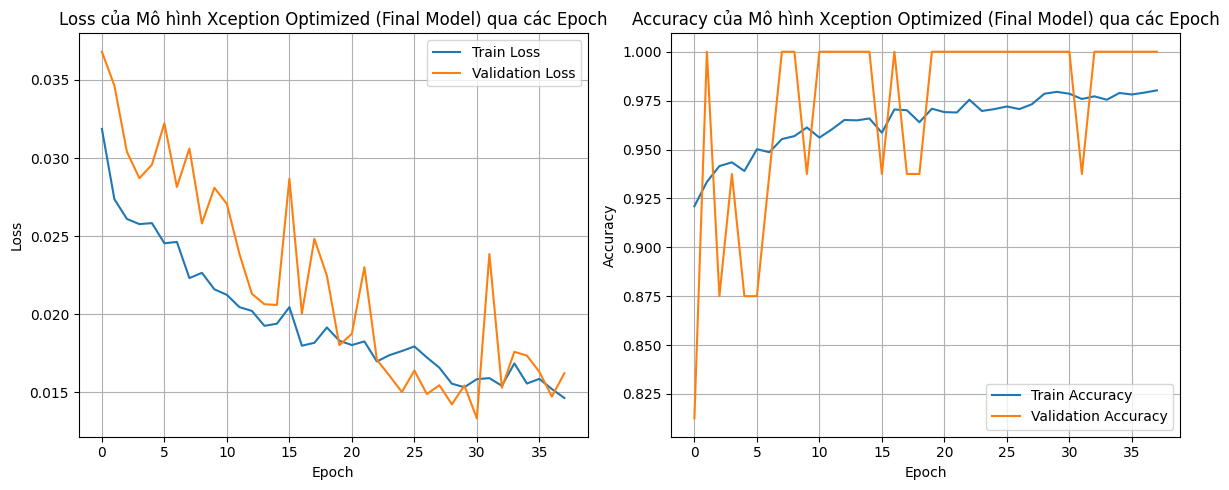


--- Đánh giá Mô hình Xception Optimized (Final) trên Tập kiểm tra ---
Test Loss: 0.0400
Test Accuracy: 0.9215
Test Precision: 0.9406
Test Recall: 0.9333
Test F1-score: 0.9369
Test AUC-ROC: 0.9667

--- Báo cáo phân loại của Mô hình Xception Optimized (Final) ---
              precision    recall  f1-score   support

      NORMAL       0.89      0.90      0.90       234
   PNEUMONIA       0.94      0.93      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624



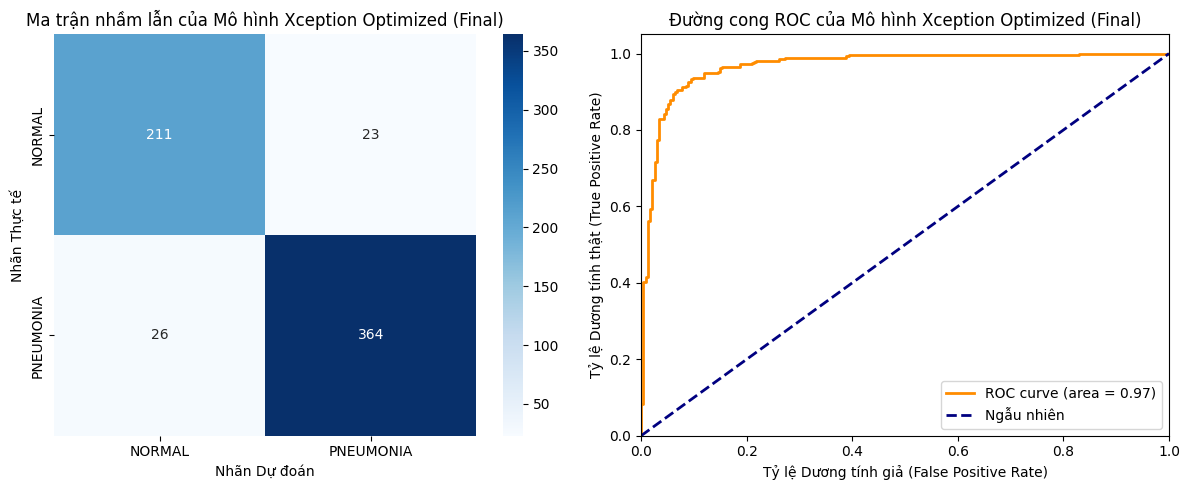

In [ ]:
print("\n--- Giai đoạn 2: Bắt đầu Fine-tuning các lớp cuối của Xception ---")

# Bỏ đóng băng N lớp cuối cùng của Xception để fine-tune
# Sử dụng fine_tune_layers_count từ HYPERPARAMS
for layer in xception_base_model.layers[-fine_tune_layers_count:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
    else:
        layer.trainable = False

print(f"Đã bỏ đóng băng {sum(1 for layer in xception_base_model.layers if layer.trainable)} lớp của Xception để tinh chỉnh sâu hơn.")

xception_model.compile(optimizer=Adam(learning_rate=lr_fine_tune),
                       loss=loss_func,
                       metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

model_checkpoint_cb_final = ModelCheckpoint( 
    'best_model_xception_final_tuned.h5', monitor='val_loss', save_best_only=True, verbose=1, save_weights_only=True
)
early_stopping_cb_final = EarlyStopping(
    monitor='val_loss', patience=PATIENCE_FINE_TUNE, restore_best_weights=True, verbose=1
)
callbacks_fine_tune = [model_checkpoint_cb_final, early_stopping_cb_final]

print(f"\n--- Đang huấn luyện Mô hình Xception Optimized (Fine-tuning cuối cùng) trong {EPOCHS_FINE_TUNE} epoch ---")
history_xception_fine_tune = xception_model.fit(
    train_generator_xception,
    epochs=EPOCHS_FINE_TUNE,
    validation_data=val_generator_xception,
    steps_per_epoch=train_generator_xception.samples // BATCH_SIZE,
    validation_steps=val_generator_xception.samples // BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=callbacks_fine_tune
)
all_histories["Xception Optimized (Final)"] = history_xception_fine_tune
plot_training_history(history_xception_fine_tune, "Xception Optimized (Final Model)")

# Tải lại trọng số tốt nhất để đánh giá
xception_model.load_weights('best_model_xception_final_tuned.h5')
xception_results = evaluate_model_performance(xception_model, test_generator_xception, "Xception Optimized (Final)", class_names_ordered)



# 6. TRỰC QUAN HÓA GRAD-CAM (CHO MÔ HÌNH TỐT NHẤT)


--- Đang tạo Trực quan hóa Grad-CAM ---
Đã thu thập 6 mẫu để trực quan hóa Grad-CAM.
Sử dụng lớp 'block14_sepconv2_bn' tại chỉ mục 130 làm lớp áp chót.
Đang tạo Grad-CAM cho mẫu 1/6
Đang tạo Grad-CAM cho mẫu 2/6
Đang tạo Grad-CAM cho mẫu 3/6
Đang tạo Grad-CAM cho mẫu 4/6
Đang tạo Grad-CAM cho mẫu 5/6
Đang tạo Grad-CAM cho mẫu 6/6


C:\Users\PV\AppData\Local\Temp\ipykernel_5804\952573527.py:124: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("jet")


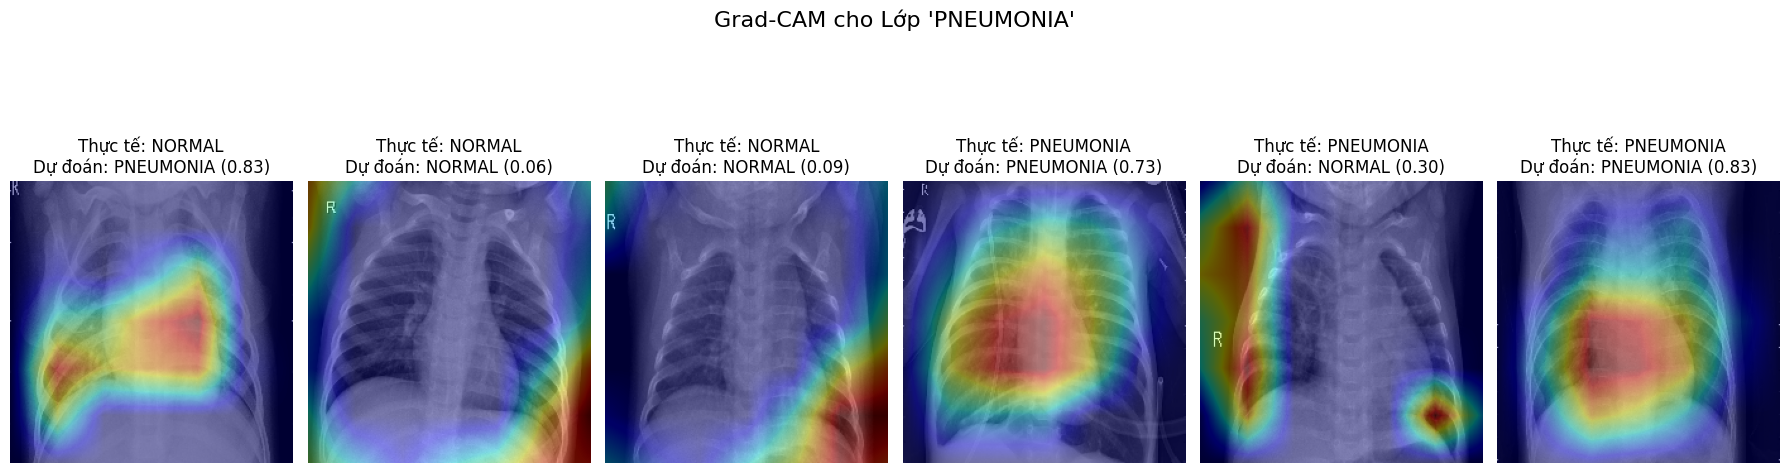

In [ ]:
print("\n--- Đang tạo Trực quan hóa Grad-CAM ---")

model_for_gradcam = xception_model

test_generator_xception.reset()
all_true_labels_gradcam = test_generator_xception.classes
all_pred_probs_gradcam = model_for_gradcam.predict(test_generator_xception, verbose=0)
all_pred_labels_gradcam = (all_pred_probs_gradcam > 0.5).astype(int).flatten()

all_filepaths = [os.path.join(test_dir, filename) for filename in test_generator_xception.filenames]

def get_sample_indices(true_labels, pred_labels, num_normal_correct=2, num_pneumonia_correct=2, num_false_positive=1, num_false_negative=1):
    normal_correct_indices = np.where((true_labels == class_indices['NORMAL']) & (pred_labels == class_indices['NORMAL']))[0]
    pneumonia_correct_indices = np.where((true_labels == class_indices['PNEUMONIA']) & (pred_labels == class_indices['PNEUMONIA']))[0]
    false_positive_indices = np.where((true_labels == class_indices['NORMAL']) & (pred_labels == class_indices['PNEUMONIA']))[0]
    false_negative_indices = np.where((true_labels == class_indices['PNEUMONIA']) & (pred_labels == class_indices['NORMAL']))[0]

    selected_indices = []
    if len(normal_correct_indices) >= num_normal_correct:
        np.random.shuffle(normal_correct_indices)
        selected_indices.extend(normal_correct_indices[:num_normal_correct])
    else:
        selected_indices.extend(normal_correct_indices)
    if len(pneumonia_correct_indices) >= num_pneumonia_correct:
        np.random.shuffle(pneumonia_correct_indices)
        selected_indices.extend(pneumonia_correct_indices[:num_pneumonia_correct])
    else:
        selected_indices.extend(pneumonia_correct_indices)
    if len(false_positive_indices) >= num_false_positive:
        np.random.shuffle(false_positive_indices)
        selected_indices.extend(false_positive_indices[:num_false_positive])
    else:
        selected_indices.extend(false_positive_indices)
    if len(false_negative_indices) >= num_false_negative:
        np.random.shuffle(false_negative_indices)
        selected_indices.extend(false_negative_indices[:num_false_negative])
    else:
        selected_indices.extend(false_negative_indices)
    selected_indices.sort()
    return selected_indices

selected_image_indices = get_sample_indices(all_true_labels_gradcam, all_pred_labels_gradcam,
                                            num_normal_correct=2,
                                            num_pneumonia_correct=2,
                                            num_false_positive=1,
                                            num_false_negative=1)
num_samples_to_visualize = len(selected_image_indices)

sample_images_preprocessed = []
sample_images_original = []
sample_labels_true = []
sample_pred_labels = []
sample_pred_probs = []

for idx in selected_image_indices:
    filepath = all_filepaths[idx]
    img_original = tf.keras.preprocessing.image.load_img(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_original_array = tf.keras.preprocessing.image.img_to_array(img_original)
    sample_images_original.append(img_original_array / 255.0)

    img_preprocessed = xception_preprocess_input(np.expand_dims(img_original_array, axis=0))[0]
    sample_images_preprocessed.append(img_preprocessed)

    sample_labels_true.append(all_true_labels_gradcam[idx])
    sample_pred_labels.append(all_pred_labels_gradcam[idx])
    sample_pred_probs.append(all_pred_probs_gradcam[idx][0])

sample_images_preprocessed = np.array(sample_images_preprocessed)
sample_images_original = np.array(sample_images_original)
sample_labels_true = np.array(sample_labels_true)
sample_pred_labels = np.array(sample_pred_labels)
sample_pred_probs = np.array(sample_pred_probs)

print(f"Đã thu thập {len(sample_images_preprocessed)} mẫu để trực quan hóa Grad-CAM.")

def score_func(output):
    return output

gradcam = Gradcam(model_for_gradcam,
                  model_modifier=ReplaceToLinear(),
                  clone=True)

last_conv_layer_name = 'block14_sepconv2_bn'
penultimate_layer_idx = -1
try:
    penultimate_layer_idx = model_for_gradcam.layers.index(model_for_gradcam.get_layer(last_conv_layer_name))
    print(f"Sử dụng lớp '{last_conv_layer_name}' tại chỉ mục {penultimate_layer_idx} làm lớp áp chót.")
except ValueError:
    print(f"Cảnh báo: Không tìm thấy lớp '{last_conv_layer_name}'. Đang thử tìm lớp Conv2D cuối cùng tự động.")
    for i in reversed(range(len(model_for_gradcam.layers))):
        if isinstance(model_for_gradcam.layers[i], tf.keras.layers.Conv2D):
            penultimate_layer_idx = i
            print(f"Sử dụng lớp Conv2D tại chỉ mục {penultimate_layer_idx} làm lớp áp chót dự phòng.")
            break
    if penultimate_layer_idx == -1:
        print("Lỗi: Không tìm thấy lớp convolutional phù hợp cho Grad-CAM. Vui lòng chỉ định 'penultimate_layer' thủ công.")

all_heatmaps = []
for i_img, img_preprocessed_single in enumerate(sample_images_preprocessed):
    print(f"Đang tạo Grad-CAM cho mẫu {i_img+1}/{len(sample_images_preprocessed)}")
    single_img_batch = np.expand_dims(img_preprocessed_single, axis=0)
    single_heatmap = gradcam(score_func, single_img_batch, penultimate_layer=penultimate_layer_idx)
    all_heatmaps.append(single_heatmap[0])
heatmaps = np.array(all_heatmaps)

f, ax = plt.subplots(nrows=1, ncols=num_samples_to_visualize, figsize=(num_samples_to_visualize * 3, 6))
if num_samples_to_visualize == 1:
    ax = [ax]

f.suptitle(f"Grad-CAM cho Lớp 'PNEUMONIA'", fontsize=16)

for i in range(num_samples_to_visualize):
    img_display = sample_images_original[i]
    current_heatmap = heatmaps[i]

    if current_heatmap.ndim == 4:
        current_heatmap = current_heatmap[0]
    if current_heatmap.ndim == 2:
        current_heatmap = np.expand_dims(current_heatmap, axis=-1)

    heatmap_resized = tf.image.resize(current_heatmap, (IMG_HEIGHT, IMG_WIDTH)).numpy()
    cmap = cm.get_cmap("jet")
    heatmap_colored = cmap(heatmap_resized[:, :, 0])[..., :3]

    superimposed_img = img_display * 0.5 + heatmap_colored * 0.5
    superimposed_img = np.clip(superimposed_img, 0, 1)

    ax[i].imshow(img_display)
    ax[i].imshow(heatmap_resized[:,:,0], cmap='jet', alpha=0.4)

    true_label_name = class_names_ordered[sample_labels_true[i]]
    predicted_label_name = class_names_ordered[sample_pred_labels[i]]
    prediction_proba_val = sample_pred_probs[i]

    ax[i].set_title(f"Thực tế: {true_label_name}\nDự đoán: {predicted_label_name} ({prediction_proba_val:.2f})")
    ax[i].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Lưu biểu đồ Grad-CAM
plt.savefig(os.path.join(PLOTS_DIR, f'gradcam_visualization.png'))
plt.show()


# 7. Bảng Tổng hợp Kết quả Cuối cùng

In [ ]:

all_results = pd.DataFrame({"Xception Optimized (Mô hình cuối cùng)": xception_results}) # Cập nhật tên mô hình trong bảng

print("\n--- Bảng Tổng hợp Kết quả ---")
print(all_results.round(4))

metrics_to_plot_bar = ['accuracy', 'f1_score', 'auc_roc', 'precision', 'recall', 'loss']
model_names_bar = all_results.columns
colors_bar = ['mediumpurple']
# --- THÔNG SỐ TỪ BÀI BÁO GỐC ĐỂ SO SÁNH ---
print("\n--- THÔNG SỐ VÀ KẾT QUẢ TỪ BÀI BÁO GỐC (Salehi et al., 2021) ĐỂ SO SÁNH ---")

original_paper_results = {
    "VGG19": {"Accuracy": 83.6, "Precision": 83.9, "Sensitivity (Recall)": 98.5, "F1-score": 83.9, "AUC": 0.78},
    "Xception": {"Accuracy": 86.0, "Precision": 85.0, "Sensitivity (Recall)": 91.8, "F1-score": 88.3, "AUC": 0.81},
    "ResNet50": {"Accuracy": 84.8, "Precision": 80.0, "Sensitivity (Recall)": 96.1, "F1-score": 87.3, "AUC": 0.81},
    "DenseNet121": {"Accuracy": 86.8, "Precision": 87.0, "Sensitivity (Recall)": 92.8, "F1-score": 89.8, "AUC": 0.86}
}

print("\nKết quả hiệu suất các mô hình từ bài báo gốc trên tập kiểm tra:")
for model_name, metrics in original_paper_results.items():
    print(f"  Mô hình: {model_name}")
    for metric, value in metrics.items():
        print(f"    {metric}: {value:.1f}%" if "Accuracy" in metric or "Sensitivity" in metric or "Precision" in metric or "F1-score" in metric else f"    {metric}: {value:.2f}")

print("\nChi tiết tập dữ liệu từ bài báo gốc (trước augmentation và balancing):")
print("  Training set: Normal=1341, Pneumonia=3875 (Tổng=5216)")
print("  Validation set: Normal=8, Pneumonia=8 (Tổng=16)")
print("  Test set: Normal=234, Pneumonia=390 (Tổng=624)")
print("\nChi tiết huấn luyện từ bài báo gốc:")
print("  Bộ tối ưu hóa: Adam")
print("  Tốc độ học: 0.001")
print("  Kích thước Batch: 15")
print("  Epoch: 50")
print("  Phần cứng: PC tiêu chuẩn với GeForce GTX 8 GB NVIDIA và 32 GB RAM")
print("  Kỹ thuật cân bằng dữ liệu: SMOTE (được áp dụng trước khi chia tập)")
print("  Kỹ thuật tăng cường dữ liệu:")
print("    Rescale: 1/255")
print("    Rotation range: 15")
print("    Width shift range: 0.1")
print("    Height shift range: 0.1")
print("    Shear range: 0.05")
print("    Zoom range: 0.05")
print("    Flipping: Horizontal/Vertical")
print("    Fill mode: Nearest")


--- Bảng Tổng hợp Kết quả ---
           Xception Optimized (Mô hình cuối cùng)
accuracy                                   0.9215
auc_roc                                    0.9667
f1_score                                   0.9369
loss                                       0.0400
precision                                  0.9406
recall                                     0.9333

--- THÔNG SỐ VÀ KẾT QUẢ TỪ BÀI BÁO GỐC (Salehi et al., 2021) ĐỂ SO SÁNH ---

Kết quả hiệu suất các mô hình từ bài báo gốc trên tập kiểm tra:
  Mô hình: VGG19
    Accuracy: 83.6%
    Precision: 83.9%
    Sensitivity (Recall): 98.5%
    F1-score: 83.9%
    AUC: 0.78
  Mô hình: Xception
    Accuracy: 86.0%
    Precision: 85.0%
    Sensitivity (Recall): 91.8%
    F1-score: 88.3%
    AUC: 0.81
  Mô hình: ResNet50
    Accuracy: 84.8%
    Precision: 80.0%
    Sensitivity (Recall): 96.1%
    F1-score: 87.3%
    AUC: 0.81
  Mô hình: DenseNet121
    Accuracy: 86.8%
    Precision: 87.0%
    Sensitivity (Recall): 92.8%
   